## 1. Data Collection

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"D:\Apollo_AgriVerse\02_Datasets\Raw\Crop\Crop_recommendation.csv")

# Display the first 5 rows of the dataset
print('First 5 rows of the dataset:')
display(df.head())

# Display basic information about the dataset
print('\nInformation about the dataset:')
df.info()

# Display descriptive statistics of the dataset
print('\nDescriptive statistics of the dataset:')
display(df.describe())

First 5 rows of the dataset:


,n,p,k,temperature,humidity,ph,rainfall,label
0,27,72,17,28.980394,57.232652,6.347929,120.743566,pigeonpeas
1,0,19,33,27.132601,95.237980,6.234458,204.720657,coconut
2,7,60,25,28.275317,82.760208,6.397637,56.049954,mungbean
3,83,94,47,27.398723,81.105234,6.469371,112.135538,banana
4,52,23,43,27.640000,71.630000,7.480000,136.580000,pumpkin



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5003 entries, 0 to 5002
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   n            5003 non-null   int64  
 1   p            5003 non-null   int64  
 2   k            5003 non-null   int64  
 3   temperature  5003 non-null   float64
 4   humidity     5003 non-null   float64
 5   ph           5003 non-null   float64
 6   rainfall     5003 non-null   float64
 7   label        5003 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 312.8+ KB

Descriptive statistics of the dataset:


,n,p,k,temperature,humidity,ph,rainfall
count,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000
mean,66.507695,52.963422,59.003798,26.983968,70.897409,6.586662,153.845569
std,38.257269,27.172014,41.676005,5.650500,18.105667,0.711750,88.869956
min,0.000000,5.000000,5.000000,10.000000,20.000000,3.504752,20.211267
25%,32.000000,32.000000,27.000000,22.795984,58.511571,6.057113,79.545000
50%,65.000000,53.000000,48.000000,26.585804,73.790000,6.570000,128.870000
75%,99.000000,70.000000,82.000000,31.072545,85.665000,7.120000,219.952417
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.000000,349.880000


## 2. Data Cleaning

In [3]:
# Check for missing values
print('Missing values in each column:')
display(df.isnull().sum())

# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f'\nNumber of duplicate rows: {num_duplicates}')

if num_duplicates > 0:
    print('Removing duplicate rows...')
    df.drop_duplicates(inplace=True)
    print(f'Number of rows after removing duplicates: {df.shape[0]}')
else:
    print('No duplicate rows found.')

Missing values in each column:


n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


Number of duplicate rows: 0
No duplicate rows found.


## 3. Data Integration

In [ ]:
# Data Integration is typically needed when combining data from multiple sources.
# For this single dataset, explicit integration steps are not required.
# If we were to merge with other datasets (e.g., weather data, soil type data),
# this section would contain `pd.merge()` or similar operations.

## 4. Data Transformation

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Encode the target variable (label) since it's categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print('Encoded labels (first 5):', y_encoded[:5])
print('Original labels (first 5):', label_encoder.inverse_transform(y_encoded[:5]))

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('\nFirst 5 rows of scaled features:')
display(X_scaled_df.head())

Encoded labels (first 5): [36 11 28  2 39]
Original labels (first 5): ['pigeonpeas' 'coconut' 'mungbean' 'banana' 'pumpkin']

First 5 rows of scaled features:


,n,p,k,temperature,humidity,ph,rainfall
0,-1.032788,0.700665,-1.007966,0.353354,-0.754798,-0.335450,-0.372514
1,-1.738607,-1.250066,-0.624014,0.026307,1.344496,-0.494891,0.572524
2,-1.555617,0.258990,-0.815990,0.228560,0.655264,-0.265605,-1.100545
3,0.431133,1.510403,-0.288055,0.073409,0.563848,-0.164809,-0.469385
4,-0.379252,-1.102841,-0.384043,0.116113,0.040466,1.255253,-0.194298


## 5. Data Reduction

In [ ]:
# Data Reduction aims to decrease the number of features or samples while preserving important information.
# For this dataset, we haven't identified a clear need for dimensionality reduction (e.g., PCA) yet.
# If feature importance or multicollinearity were issues, we might apply techniques like PCA or feature selection here.

## 6. Data Splitting

In [5]:
from sklearn.model_selection import train_test_split

# Split the transformed data into training and testing sets
# Using 80% for training and 20% for testing
# stratify=y_encoded ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (4002, 7)
X_test shape: (1001, 7)
y_train shape: (4002,)
y_test shape: (1001,)


## 7. Feature Engineering

In [6]:
# Feature engineering involves creating new features from existing ones to improve model performance.
# Let's create a simple example: a ratio of Nitrogen to Potassium (N/K) if K is not zero.

# Create a copy to avoid SettingWithCopyWarning
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Add N_to_K_Ratio feature
X_train_fe['N_to_K_Ratio'] = X_train_fe.apply(lambda row: row['n'] / row['k'] if row['k'] != 0 else 0, axis=1)
X_test_fe['N_to_K_Ratio'] = X_test_fe.apply(lambda row: row['n'] / row['k'] if row['k'] != 0 else 0, axis=1)

print('\nFirst 5 rows of X_train with new feature:')
display(X_train_fe.head())
print('\nFirst 5 rows of X_test with new feature:')
display(X_test_fe.head())


First 5 rows of X_train with new feature:


,n,p,k,temperature,humidity,ph,rainfall,N_to_K_Ratio
995,0.640264,1.252759,-0.504029,0.211690,0.554721,1.086638,-1.202727,-1.270293
274,0.195860,-0.329910,-0.672008,-0.834340,-1.344874,-0.121771,0.143307,-0.291454
4229,-1.607899,-1.654935,-1.295930,-2.823092,1.178183,-0.033818,-0.462227,1.240730
3471,-1.241919,-0.624360,-0.887981,-0.272052,-0.681831,-0.592541,-1.089311,1.398588
1427,-1.477192,0.627053,-0.959972,-0.377842,-0.105863,0.963588,-1.263036,1.538787



First 5 rows of X_test with new feature:


,n,p,k,temperature,humidity,ph,rainfall,N_to_K_Ratio
4339,-0.143979,-0.992422,-0.384043,-1.567092,0.823172,-0.810284,-1.012767,0.374903
2540,-0.719091,-0.366716,0.263876,-0.328140,0.670718,-1.147514,1.384571,-2.725107
2874,1.215376,-1.728547,-0.168070,0.137914,1.074813,0.216841,-1.447535,-7.231354
3702,1.712063,-0.145879,1.343742,-0.441415,-0.472684,-1.316130,-0.126440,1.274101
1145,-1.058929,0.443021,0.335867,1.032938,-0.715174,1.676791,0.547196,-3.152822


## 8. Data Validation

In [7]:
# Data Validation ensures the consistency and quality of the prepared data.
# We can check for ranges, distributions, and ensure no unexpected values or errors after transformations.

print('\nValidation checks on training data:')
print(f"Shape of X_train_fe: {X_train_fe.shape}")
print(f"Missing values in X_train_fe: {X_train_fe.isnull().sum().sum()}")
print(f"Min/Max of N_to_K_Ratio in X_train_fe: {X_train_fe['N_to_K_Ratio'].min():.2f}/{X_train_fe['N_to_K_Ratio'].max():.2f}")

print('\nValidation checks on testing data:')
print(f"Shape of X_test_fe: {X_test_fe.shape}")
print(f"Missing values in X_test_fe: {X_test_fe.isnull().sum().sum()}")
print(f"Min/Max of N_to_K_Ratio in X_test_fe: {X_test_fe['N_to_K_Ratio'].min():.2f}/{X_test_fe['N_to_K_Ratio'].max():.2f}")

# Check if the number of classes in y_train and y_test are consistent
print(f'\nUnique classes in y_train: {len(set(y_train))}')
print(f'Unique classes in y_test: {len(set(y_test))}')

# Further checks could involve plotting distributions of engineered features or cross-checking statistics.


Validation checks on training data:
Shape of X_train_fe: (4002, 8)
Missing values in X_train_fe: 0
Min/Max of N_to_K_Ratio in X_train_fe: -19933.60/13053.71

Validation checks on testing data:
Shape of X_test_fe: (1001, 8)
Missing values in X_test_fe: 0
Min/Max of N_to_K_Ratio in X_test_fe: -12188.75/11906.32

Unique classes in y_train: 50
Unique classes in y_test: 50


## Data Loading and Initial Exploration

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Crop_recommendation.csv')

# Display the first 5 rows of the dataset
print('First 5 rows of the dataset:')
display(df.head())

# Display basic information about the dataset
print('\nInformation about the dataset:')
df.info()

# Display descriptive statistics of the dataset
print('\nDescriptive statistics of the dataset:')
display(df.describe())

FileNotFoundError: [Errno 2] No such file or directory: '/content/Crop_recommendation.csv'

## Data Preprocessing: Handling Missing Values and Duplicates

In [9]:
# Check for missing values
print('Missing values in each column:')
display(df.isnull().sum())

# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f'\nNumber of duplicate rows: {num_duplicates}')

if num_duplicates > 0:
    print('Removing duplicate rows...')
    df.drop_duplicates(inplace=True)
    print(f'Number of rows after removing duplicates: {df.shape[0]}')

Missing values in each column:


n              0
p              0
k              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


Number of duplicate rows: 0


## Exploratory Data Analysis: Visualizing Distributions

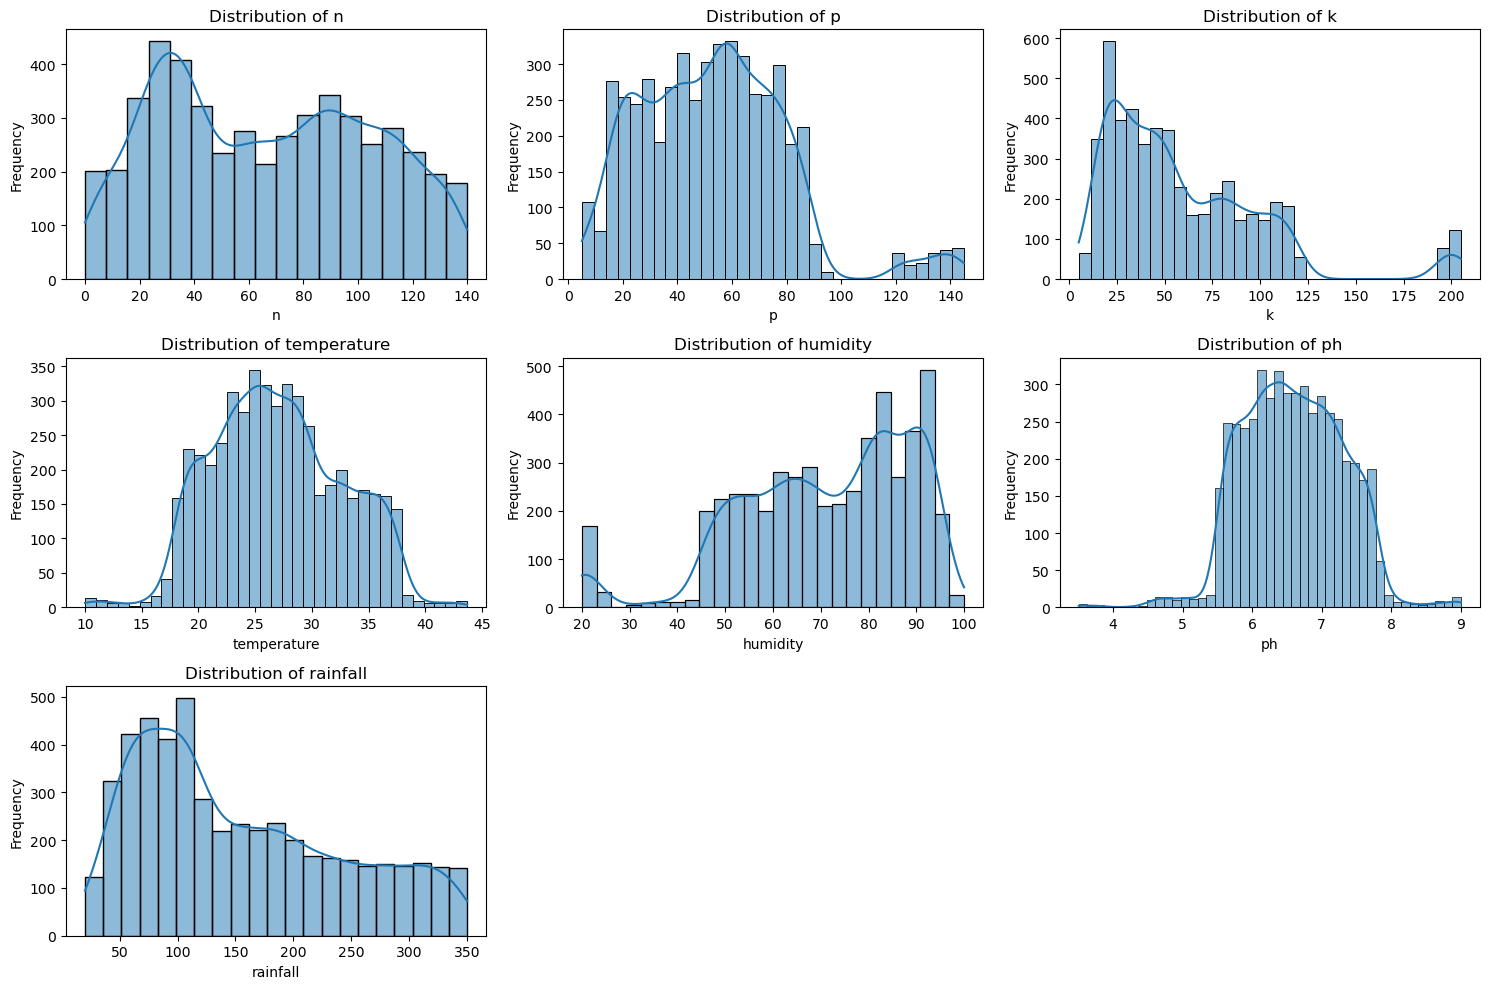

In [10]:
# Visualize the distribution of numerical features

# Get numerical columns (excluding 'label' if it's categorical)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'label' in numerical_cols:
    numerical_cols.remove('label') # Assuming 'label' is the target and might be categorical

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features (Crop Labels)

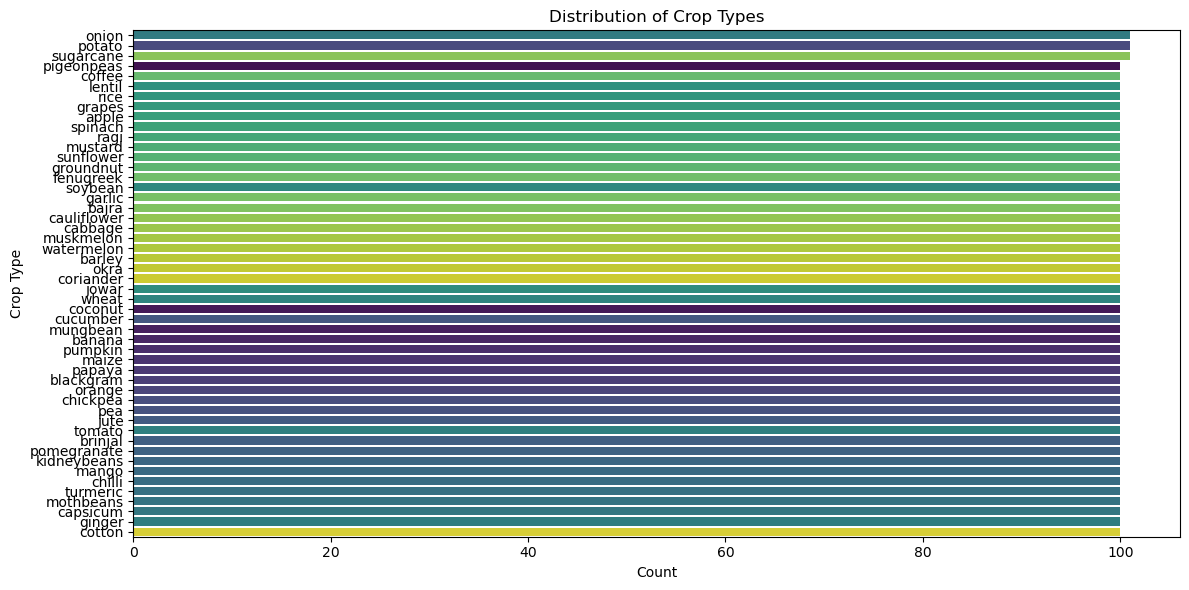

In [11]:
# Visualize the distribution of the 'label' column
plt.figure(figsize=(12, 6))
sns.countplot(y='label', data=df, palette='viridis', hue='label', legend=False, order = df['label'].value_counts().index)
plt.title('Distribution of Crop Types')
plt.xlabel('Count')
plt.ylabel('Crop Type')
plt.tight_layout()
plt.show()

## Exploratory Data Analysis: Correlation Matrix

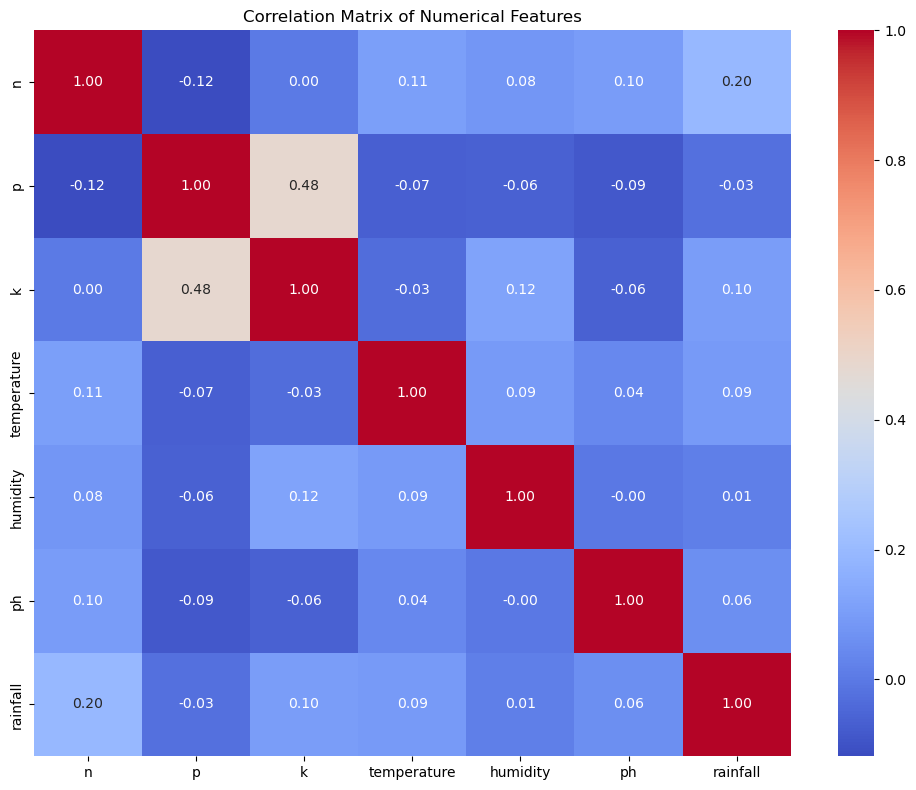

In [12]:
# Calculate the correlation matrix for numerical features
# Redefine numerical_cols as it was defined in a previous cell's scope
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'label' in numerical_cols:
    numerical_cols.remove('label')

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

## Data Preprocessing: Feature Scaling and Encoding

In [13]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

# Encode the target variable (label) since it's categorical
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print('Encoded labels:', y_encoded[:5])
print('Original labels:', label_encoder.inverse_transform(y_encoded[:5]))

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('\nFirst 5 rows of scaled features:')
display(X_scaled_df.head())

Encoded labels: [36 11 28  2 39]
Original labels: ['pigeonpeas' 'coconut' 'mungbean' 'banana' 'pumpkin']

First 5 rows of scaled features:


,n,p,k,temperature,humidity,ph,rainfall
0,-1.032788,0.700665,-1.007966,0.353354,-0.754798,-0.335450,-0.372514
1,-1.738607,-1.250066,-0.624014,0.026307,1.344496,-0.494891,0.572524
2,-1.555617,0.258990,-0.815990,0.228560,0.655264,-0.265605,-1.100545
3,0.431133,1.510403,-0.288055,0.073409,0.563848,-0.164809,-0.469385
4,-0.379252,-1.102841,-0.384043,0.116113,0.040466,1.255253,-0.194298


In [15]:
import os
import pandas as pd

# Folder path
save_path = r"D:\Apollo_AgriVerse\02_Datasets\Processed\crop"

# Create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save processed datasets
X_train_fe.to_csv(os.path.join(save_path, "X_train_processed.csv"), index=False)
X_test_fe.to_csv(os.path.join(save_path, "X_test_processed.csv"), index=False)

pd.DataFrame(y_train, columns=["label"]).to_csv(
    os.path.join(save_path, "y_train.csv"),
    index=False
)

pd.DataFrame(y_test, columns=["label"]).to_csv(
    os.path.join(save_path, "y_test.csv"),
    index=False
)

print("✅ All processed files saved successfully!")
print(f"Saved to: {save_path}")

✅ All processed files saved successfully!
Saved to: D:\Apollo_AgriVerse\02_Datasets\Processed\crop
